In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
import math

# -----------------------------------
# settings
# -----------------------------------
dt = 0.01
eps = 0.01
Time_steps = 1500
iters = 300

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
class LorenzStep(nn.Module):
    def __init__(self, dt=0.01):
        super().__init__()
        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0 / 3.0
        self.dt = dt

    def forward(self, x):
        X = x[:, 0]
        Y = x[:, 1]
        Z = x[:, 2]

        dx = self.sigma * (Y - X)
        dy = X * (self.rho - Z) - Y
        dz = X * Y - self.beta * Z

        # Euler step
        X = X + self.dt * dx
        Y = Y + self.dt * dy
        Z = Z + self.dt * dz

        return torch.stack([X, Y, Z], dim=1)


model = LorenzStep(dt=dt).to(device)

In [4]:
def loss_fn(A,B):
  return torch.mean((A - B)**2)


Running NIO for T = 100
iter 0 loss -0.016852151602506638
iter 100 loss -0.14786651730537415
iter 200 loss -0.21677257120609283
T = 100, avg final separation = 2.072556

Running NIO for T = 200
iter 0 loss -0.05820757523179054
iter 100 loss -0.010906139388680458
iter 200 loss -0.007966866716742516
T = 200, avg final separation = 0.322870

Running NIO for T = 300
iter 0 loss -1.5582672357559204
iter 100 loss -0.10991709679365158
iter 200 loss -0.5671527981758118
T = 300, avg final separation = 1.603423

Running NIO for T = 400
iter 0 loss -3.6127045154571533
iter 100 loss -0.788984477519989
iter 200 loss -0.4076552391052246
T = 400, avg final separation = 3.273221

Running NIO for T = 500
iter 0 loss -5.632447719573975
iter 100 loss -2.415933847427368
iter 200 loss -3.349513053894043
T = 500, avg final separation = 6.113206

Running NIO for T = 600
iter 0 loss -14.068197250366211
iter 100 loss -12.20889949798584
iter 200 loss -7.665356159210205
T = 600, avg final separation = 10.690630

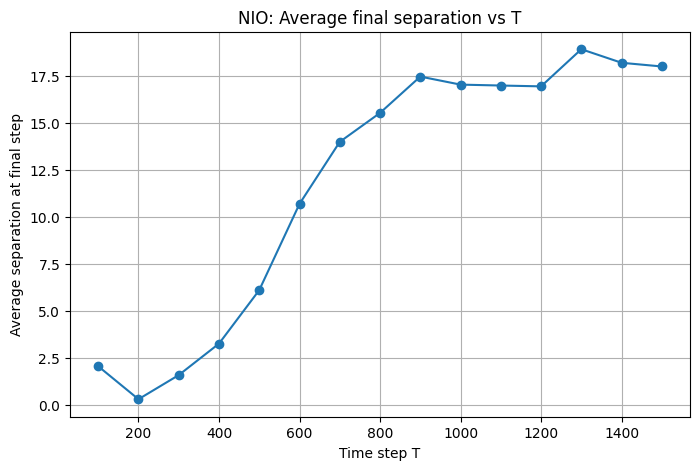

In [5]:

# bounds
low  = torch.tensor([-20.0, -30.0, 0.0], device=device)
high = torch.tensor([20.0, 30.0, 50.0], device=device)

N = 200   # 200 random points
T_list = list(range(100, 1501, 100))

avg_sep_list = []

for Time_steps in T_list:
    print(f"\nRunning NIO for T = {Time_steps}")

    # -----------------------------------
    # 200 random initial latent points
    # -----------------------------------
    initial_input = torch.randn(N, 3, device=device)

    z_init = initial_input.clone().detach().requires_grad_(True)
    optimizer = optim.Adam([z_init], lr=0.05)

    # -----------------------------------
    # NIO optimization for this T
    # -----------------------------------
    for i in range(iters):
        x0 = low + (high - low) * torch.sigmoid(z_init)

        xA = x0
        xB = x0 + eps   # keep your original form

        trajA = []
        trajB = []

        trajA.append(xA)
        trajB.append(xB)

        for t in range(Time_steps):
            xA = model(xA)
            xB = model(xB)

            trajA.append(xA)
            trajB.append(xB)

        trajA = torch.stack(trajA)   # [Time_steps+1, N, 3]
        trajB = torch.stack(trajB)

        # maximize trajectory divergence
        loss = -(loss_fn(trajA, trajB))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print("iter", i, "loss", loss.item())

    # -----------------------------------
    # after NIO, find separation at final step T
    # -----------------------------------
    with torch.no_grad():
        x0 = low + (high - low) * torch.sigmoid(z_init)

        xA = x0
        xB = x0 + eps

        for t in range(Time_steps):
            xA = model(xA)
            xB = model(xB)

        # final separation at time step T
        final_sep = torch.norm(xA - xB, dim=1)   # [N]

        # average over 200 random points
        avg_sep = final_sep.mean().item()
        avg_sep_list.append(avg_sep)

        print(f"T = {Time_steps}, avg final separation = {avg_sep:.6f}")

# -----------------------------------
# plot graph
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.plot(T_list, avg_sep_list, marker='o')
plt.xlabel("Time step T")
plt.ylabel("Average separation at final step")
plt.title("NIO: Average final separation vs T")
plt.grid(True)
plt.show()

In [6]:
############ calculate the theroritical value ####################
lam = 0.9        # theory lyapunov value
eps = 0.01
L = 20
dt = 0.01

# Compute Topt
Topt = math.log(L / eps) / (lam * dt)
print(f"Topt = {Topt}")

Topt = 844.5447177268979


In [7]:
theory_sep = [
    eps * math.exp(lam * T * dt)
    for T in T_list
]

Text(0.5, 1.0, 'NIO vs Theory Separation')

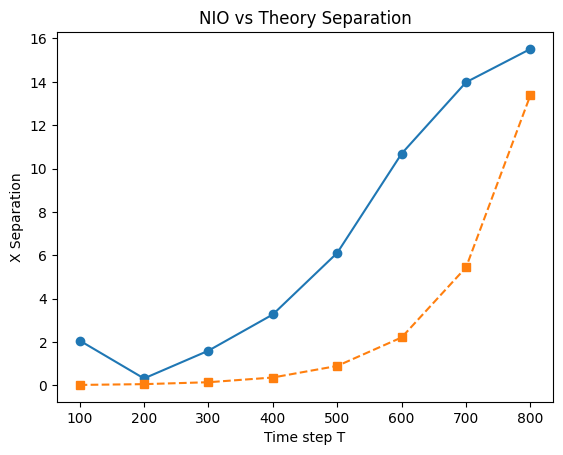

In [8]:
plot = plt.plot(T_list[:-7], avg_sep_list[:-7], marker='o', label="NIO Avg X Separation")
plot = plt.plot(T_list[:-7], theory_sep[:-7], marker='s',linestyle='--', label="Theory Separation " )
plt.xlabel("Time step T")
plt.ylabel("X Separation")
plt.title("NIO vs Theory Separation")